In [1]:
import os
import struct
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
import torch.optim.lr_scheduler as lr_scheduler
import time
import csv
import glob
from diffraction_utils import load_experimental_data
from load_xml_phases import *
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pandas as pd

./libCIFtoDB.so


In [9]:
difr_dir = "../../DiffractNet_nn_data_2.5/"
Data_name = "s2.5"
os.makedirs(difr_dir, exist_ok=True)

# Автовыбор вычислительного устройства
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print('device =', device)

# Вычисляем размер входа для свертки
input_size = 4001
num_phases = 12

xml_name = 'OSO'
model_ver = 'light_3'
wghts_fname = f'weights3_{xml_name}_{model_ver}.pth'
#csv_res_fname = f"{xml_name}_{model_ver}.csv"

inp_data = []
out_data = []

PHASES_INFO = []

experiment_folder = 'XY_OSO_midKO'

device = cpu


In [4]:
# Создаем словарь для сопоставления имен файлов и целевых значений
target_values = {
    'Бо1125_180121.xy': np.array([0.42, 0.25, 42.72, 44.65, 2.22, 8.05, 0.00, 1.40, 0.28, 0.00, 0.01, 0.00]),
    'Бо2074_200121.xy': np.array([0.50, 0.24, 58.48, 27.85, 2.88, 7.90, 0.05, 1.62, 0.48, 0.00, 0.01, 0.00]),
    'Бо2077_200121.xy': np.array([0.40, 0.93, 67.24, 18.25, 3.63, 7.51, 0.03, 1.60, 0.42, 0.00, 0.00, 0.00]),
    'Бр1026_181220.xy': np.array([2.72, 2.78, 47.84, 28.73, 1.20, 14.57, 0.07, 2.06, 0.03, 0.00, 0.00, 0.00]),
    'Бр1071_241220.xy': np.array([1.22, 0.63, 50.30, 30.39, 1.60, 13.97, 0.06, 1.84, 0.00, 0.00, 0.00, 0.00]),
    'Бр1307_2_181220.xy': np.array([0.68, 1.17, 86.07, 0.94, 3.65, 1.29, 4.55, 0.31, 0.79, 0.05, 0.52, 0.00]),
    'Бр1356_251220.xy': np.array([1.67, 2.21, 78.72, 2.34, 7.51, 3.22, 2.43, 1.09, 0.51, 0.28, 0.02, 0.00]),
    'Бр1425_241220.xy': np.array([0.90, 1.56, 81.95, 1.43, 6.32, 2.76, 3.40, 0.85, 0.68, 0.16, 0.00, 0.00]),
    'Бр1428_241220.xy': np.array([1.07, 2.47, 63.14, 15.82, 0.80, 14.47, 0.66, 1.58, 0.00, 0.00, 0.00, 0.00]),
    'Бр1566_281220.xy': np.array([0.72, 3.95, 70.88, 5.65, 6.65, 9.87, 0.12, 2.14, 0.00, 0.00, 0.01, 0.00]),
    'В506_140121.xy': np.array([2.11, 2.59, 54.29, 21.35, 2.26, 15.51, 0.06, 1.59, 0.24, 0.00, 0.01, 0.00]),
    'В508_140121.xy': np.array([2.12, 3.48, 48.43, 27.17, 1.62, 15.24, 0.05, 1.63, 0.26, 0.00, 0.01, 0.00]),
    'В549_150121.xy': np.array([1.01, 3.74, 78.07, 0.43, 13.37, 0.44, 1.63, 0.24, 0.17, 0.00, 0.89, 0.00]),
    'В574_150121.xy': np.array([0.52, 1.16, 52.24, 24.86, 1.70, 16.05, 0.03, 3.32, 0.11, 0.00, 0.00, 0.00]),
    'В583_180121.xy': np.array([0.45, 1.25, 52.71, 24.86, 2.10, 16.14, 0.06, 2.38, 0.04, 0.00, 0.01, 0.00]),
    'И103_291220.xy': np.array([1.02, 3.74, 53.23, 30.05, 1.25, 5.35, 4.20, 1.05, 0.00, 0.11, 0.00, 0.00]),
    'И128_120121.xy': np.array([1.16, 3.16, 59.49, 23.44, 1.06, 7.46, 2.84, 1.33, 0.00, 0.06, 0.00, 0.00]),
    'И538_110121.xy': np.array([1.42, 0.97, 72.78, 9.48, 2.78, 10.23, 0.42, 1.19, 0.00, 0.72, 0.00, 0.00]),
    'И644_110121.xy': np.array([1.24, 4.00, 73.64, 6.08, 7.94, 4.33, 1.11, 0.93, 0.00, 0.63, 0.00, 0.00]),
    'И743_211220.xy': np.array([0.39, 1.37, 88.97, 0.92, 2.73, 0.32, 4.03, 0.12, 0.42, 0.28, 0.44, 0.00]),
    'И9085_130121.xy': np.array([0.48, 0.14, 42.95, 44.21, 1.04, 10.34, 0.07, 0.71, 0.06, 0.00, 0.00, 0.00]),
    'К173_210121.xy': np.array([0.68, 2.13, 45.16, 36.51, 1.06, 10.94, 0.07, 2.73, 0.29, 0.43, 0.00, 0.00]),
    'К1898_270121.xy': np.array([1.89, 1.83, 55.79, 17.94, 2.05, 13.11, 0.43, 2.62, 0.14, 4.21, 0.00, 0.00]),
    'К2019_270121.xy': np.array([1.30, 3.43, 67.70, 7.81, 2.77, 10.36, 0.05, 2.19, 0.40, 4.00, 0.00, 0.00]),
    'К2022_280121.xy': np.array([1.18, 1.49, 58.94, 15.68, 2.12, 13.57, 0.08, 2.58, 0.46, 3.91, 0.00, 0.00]),
    'К2035_280121.xy': np.array([0.99, 1.88, 57.56, 16.03, 2.68, 12.59, 0.11, 2.36, 0.43, 5.37, 0.00, 0.00]),
    'К2041_280121.xy': np.array([0.95, 2.44, 49.16, 25.80, 1.25, 13.73, 0.07, 2.76, 0.22, 3.62, 0.00, 0.00]),
    'К2042_290121.xy': np.array([0.87, 0.92, 83.39, 0.71, 0.34, 0.11, 6.30, 0.00, 0.24, 4.62, 2.51, 0.00]),
    'С152_161220.xy': np.array([0.26, 1.65, 33.93, 52.38, 0.73, 9.34, 0.27, 0.99, 0.04, 0.38, 0.04, 0.00]),
    'С207_181220.xy': np.array([0.32, 0.61, 42.08, 44.57, 0.83, 9.56, 0.29, 1.31, 0.00, 0.42, 0.00, 0.00]),
    'С294_211220.xy': np.array([0.77, 2.01, 57.04, 26.08, 2.25, 8.96, 0.34, 1.74, 0.00, 0.83, 0.00, 0.00]),
    'С343_221220.xy': np.array([1.84, 1.80, 51.13, 33.75, 1.11, 7.74, 0.75, 1.31, 0.00, 0.56, 0.00, 0.00]),
    'С367_231220.xy': np.array([0.47, 1.94, 56.72, 26.99, 1.58, 9.51, 0.39, 1.60, 0.00, 0.81, 0.00, 0.00]),
    'С455_171220.xy': np.array([0.20, 2.09, 32.42, 53.03, 0.80, 9.33, 0.46, 1.01, 0.00, 0.28, 0.38, 0.00]),
    'С479_231220.xy': np.array([0.73, 1.32, 53.55, 31.52, 1.41, 9.09, 0.29, 1.45, 0.00, 0.63, 0.00, 0.00]),
    'С490_231220.xy': np.array([1.05, 2.49, 55.01, 30.80, 1.07, 4.45, 3.10, 1.48, 0.01, 0.55, 0.00, 0.00]),
    'дБо2058д_240521.xy': np.array([0.00, 0.74, 10.33, 59.61, 2.16, 5.09, 0.13, 21.81, 0.15, 0.00, 0.00, 0.00]),
    'дБо2082д_280521.xy': np.array([0.62, 0.35, 85.91, 0.00, 0.00, 0.00, 3.22, 0.00, 9.42, 0.06, 0.17, 0.00]),
    'дБр1307д_220421.xy': np.array([0.93, 0.36, 85.71, 0.39, 0.35, 0.03, 9.36, 0.00, 0.24, 0.00, 1.22, 1.43]),
    'дБр1552д_020621.xy': np.array([0.89, 0.00, 85.48, 0.25, 0.34, 0.00, 6.05, 0.03, 0.58, 0.00, 0.37, 6.00]),
    'дК1132д_180521.xy': np.array([2.42, 1.47, 75.98, 0.48, 0.61, 0.17, 9.58, 0.06, 4.70, 0.16, 2.08, 2.28]),
    'дК1585д_170521.xy': np.array([0.43, 1.17, 84.69, 0.00, 0.00, 0.00, 9.71, 0.00, 1.83, 1.65, 0.46, 0.00]),
    'дК180д_290421.xy': np.array([0.19, 1.93, 26.94, 42.17, 4.99, 17.44, 0.06, 5.90, 0.00, 0.40, 0.00, 0.00]),
    'дС132д_210421.xy': np.array([0.29, 2.38, 26.13, 41.49, 2.17, 16.56, 0.10, 10.58, 0.27, 0.03, 0.00, 0.00]),
    'дС321д_120521.xy': np.array([0.42, 1.90, 20.31, 38.45, 3.73, 20.36, 0.10, 14.56, 0.00, 0.02, 0.16, 0.00]),
    'дС323д_170521.xy': np.array([0.17, 1.65, 21.48, 30.25, 7.69, 19.54, 0.03, 18.75, 0.14, 0.07, 0.24, 0.00])
}

# Достаем эксперементальные данные

In [59]:
experimental_data = load_experimental_data(experiment_folder)

exp_data = []
exp_data_phases = []
for filename, intensities in experimental_data.items():
    exp_data.append(intensities[1:])
    exp_data_phases.append(target_values.get(filename))

exp_data = np.array(exp_data)
# exp_data.shape
exp_data_phases


[array([4.200e-01, 1.900e+00, 2.031e+01, 3.845e+01, 3.730e+00, 2.036e+01,
        1.000e-01, 1.456e+01, 0.000e+00, 2.000e-02, 1.600e-01, 0.000e+00]),
 array([2.720e+00, 2.780e+00, 4.784e+01, 2.873e+01, 1.200e+00, 1.457e+01,
        7.000e-02, 2.060e+00, 3.000e-02, 0.000e+00, 0.000e+00, 0.000e+00]),
 array([2.900e-01, 2.380e+00, 2.613e+01, 4.149e+01, 2.170e+00, 1.656e+01,
        1.000e-01, 1.058e+01, 2.700e-01, 3.000e-02, 0.000e+00, 0.000e+00]),
 array([ 0.39,  1.37, 88.97,  0.92,  2.73,  0.32,  4.03,  0.12,  0.42,
         0.28,  0.44,  0.  ]),
 array([ 0.48,  0.14, 42.95, 44.21,  1.04, 10.34,  0.07,  0.71,  0.06,
         0.  ,  0.  ,  0.  ]),
 array([ 1.02,  3.74, 53.23, 30.05,  1.25,  5.35,  4.2 ,  1.05,  0.  ,
         0.11,  0.  ,  0.  ]),
 array([ 1.22,  0.63, 50.3 , 30.39,  1.6 , 13.97,  0.06,  1.84,  0.  ,
         0.  ,  0.  ,  0.  ]),
 array([1.300e+00, 3.430e+00, 6.770e+01, 7.810e+00, 2.770e+00, 1.036e+01,
        5.000e-02, 2.190e+00, 4.000e-01, 4.000e+00, 0.000e+00, 0.000

In [40]:
def predict_experimental_data(model, experimental_data, input_size):
    predictions = []
    total_difference = 0.0
    exp_samples_nb = 0

    diff_by_phases = []
    for i in range(num_phases):
        diff_by_phases.append(0)

    for filename, intensities in experimental_data.items():
        print(intensities.shape)
        interpolated_intensities = torch.tensor(intensities, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)[:,:,1:]
        model.eval()
        with torch.no_grad():
            predicted_weights = model(interpolated_intensities)

        # Умножаем предсказанные веса на 100
        #predicted_weights *= 100
        
        predictions.append((filename, predicted_weights.squeeze().cpu().numpy()))

        # Сравнение с целевыми значениями, если они есть
        if filename in target_values:
            target = target_values[filename]
            curr_phases = np.square(predicted_weights.squeeze().cpu().numpy() - target*0.01)
            total_difference += curr_phases.sum()
            diff_by_phases += curr_phases  # Аккумулируем разности для каждой фазы
            exp_samples_nb += 1

    if exp_samples_nb > 0:
        total_difference = (total_difference / exp_samples_nb) / num_phases
        diff_by_phases /= exp_samples_nb  # Вычисляем средние значения для каждой фазы
    else:
        total_difference = 0.0
        diff_by_phases = np.zeros(num_phases)

    return total_difference, diff_by_phases, exp_samples_nb

def load_batch_inp_file(file_name):
    if os.path.exists(file_name):
        with open(file_name, 'rb') as f:
            while True:
                data = f.read(struct.calcsize(f'{input_size}f'))
                if not data:
                    break
                inp = struct.unpack(f'{input_size}f', data)
                inp_data.append(np.array(inp))


def load_batch_out_file(file_name):
    if os.path.exists(file_name):
        with open(file_name, 'rb') as f:
            while True:
                data = f.read(struct.calcsize(f'{num_phases}f'))
                if not data:
                    break
                out = struct.unpack(f'{num_phases}f', data)
                out_data.append(np.array(out))

def find_index_of_max(float_array):
    max_index = np.argmax(float_array)
    return max_index

In [41]:
#ViT_parametrized
gl_emb_dim = 40
gl_num_layers = 2
gl_nheads = 2
gl_dim_feedforward = 256
gl_dropout = 0.1
gl_CAWR_T = 30
learn_rate = 1E-4
num_epochs = 1

for gl_nheads in [10]:   
    for gl_dim_feedforward in [256]:    
        Model_name = f"_test_ViT_emb{gl_emb_dim}_h{gl_nheads}_ff{gl_dim_feedforward}_L{gl_num_layers}_CAWR{gl_CAWR_T}_LR{learn_rate}"
        csv_res_fname = f"Run_results/{xml_name}_{Data_name}_{Model_name}.csv"
        print(csv_res_fname)
        class DiffractionNet(nn.Module):
            def __init__(self, input_size, num_phases):
                super().__init__()
                self.emb_dim=gl_emb_dim
                self.fc_layers = nn.Sequential(            
                    nn.Linear(4000+self.emb_dim, num_phases)
                )
                self.transformer = nn.TransformerEncoder(
                    nn.TransformerEncoderLayer(d_model=self.emb_dim, nhead=gl_nheads, dim_feedforward=gl_dim_feedforward, dropout=gl_dropout, batch_first=True),
                    num_layers=gl_num_layers
                )
                self.positional_embedding=nn.Parameter(torch.randn(1, 1, self.emb_dim))
            
            def forward(self, x):
                #x = x.view(-1,self.emb_dim,int(4000/self.emb_dim)).permute(0, 2, 1)
                x = x.view(-1,int(4000/self.emb_dim),self.emb_dim)
                positional_embeddings = self.positional_embedding.expand(x.shape[0], 1, self.emb_dim)
                print(positional_embeddings.shape)
                print(x.shape)
                x = torch.cat((positional_embeddings, x), dim=1)
                x = self.transformer(x)
                x = x.view(-1,4000+self.emb_dim)
                x = self.fc_layers(x)
                x = F.softmax(x, dim=1)
                return x
        
        # Создание экземпляра модели
        model = DiffractionNet(input_size, num_phases)#.to(device)
        print(model)
        pytorch_total_params = sum(p.numel() for p in model.parameters())
        print("Total params",pytorch_total_params)
        
        #print('Start training')
        #learn_rate = 1E-4
        # Определяем критерий потерь и оптимизатор
        criterion = nn.MSELoss(reduction='none')  # Используем reduction='none' для получения ошибки для каждого элемента в батче
        optimizer = optim.AdamW(model.parameters(), lr=learn_rate, weight_decay=learn_rate*0.1)
        scheduler = lr_scheduler.CosineAnnealingWarmRestarts(optimizer,T_0=gl_CAWR_T)
        
        # Определяем метки классов для балансировки
        train_labels = np.array([find_index_of_max(out) for out in train_outputs])
        #print('train_labels',train_labels)
        class_counts = np.bincount(train_labels.astype(np.int64))
        #print(f'Category class_counts = {class_counts}')
        # Добавляем сглаживание для предотвращения деления на ноль
        #smoothing_factor = 1e-3
        #class_weights = 1. / (class_counts + smoothing_factor)
        class_weights = 1. / class_counts
        sample_weights = class_weights[train_labels]
        sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)
        # Загрузка данных
        train_dataloader = DataLoader(train_dataset, batch_size=128, sampler=sampler)
        test_dataloader = DataLoader(test_dataset, batch_size=128, shuffle=False)
        
        n_train_iter = len(train_dataloader)
        n_test_iter = len(test_dataloader)
        print(f'train_iter: {n_train_iter}, test_iter: {n_test_iter}')
        # Инициализация списков для хранения значений потерь
        train_losses = []
        test_losses = []
        
        # Инициализация списков для хранения значений потерь для каждого параметра
        train_param_losses = [[] for _ in range(num_phases)]
        test_param_losses = [[] for _ in range(num_phases)]
        
        # Создание и запись заголовков в CSV-файл
        with open(csv_res_fname, mode='w', newline='') as file:
            writer = csv.writer(file, delimiter=';')
            header = ['Time', 'Epoch', 'Train Loss', 'Test Loss', 'Exp_Diff'] + \
                     [f'Train_{i + 1}' for i in range(num_phases)] + \
                     [f'Test_{i + 1}' for i in range(num_phases)] + \
                     [f'Exp_{i + 1}' for i in range(num_phases)]
            writer.writerow(header)
        
        
        
        total_exp_diff = 0.0
        ph_exp_diff = []
        
        pre_fitness = 1E6
        
        train_all_losses = []
        test_all_losses = []
        train_batch_losses = []
        test_batch_losses = []
        experimental_losses = []
        
        #scheduler = lr_scheduler.CosineAnnealingWarmRestarts(optimizer,T_0=30)
        
        start_time = time.time()  # Запоминаем время начала обучения
        
        for epoch in range(num_epochs):
            model.train()
            running_train_loss = 0.0
            running_train_param_losses = [0.0 for _ in range(num_phases)]
            iters = 0
            #train_batch_losses = []
            for inputs, outputs in train_dataloader:
                #inputs, outputs = inputs.to(device), outputs.to(device)
                #inputs = inputs.view(-1,40,int(4000/40)).permute(0, 2, 1)
                #inputs = inputs.view(-1,int(4000/40),40)#.permute(0, 2, 1)
                #print(inputs.shape)
                
                optimizer.zero_grad()
                predictions = model(inputs)        
                loss = criterion(predictions, outputs)
                loss.mean().backward()  # Средняя ошибка по всем элементам в батче
                # Градиенты масштабируются, если их общая норма > 1.0
                #torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                #running_train_loss += loss.mean().item()
                #for i in range(num_phases):
                #    running_train_param_losses[i] += loss[:, i].mean().item()
                iters += 1
                #train_batch_losses.append(loss.mean(axis=1).cpu().detach().numpy())
        
                if iters % 5000 == 0:
                    print(f"Iteration {iters}")
                break
            #train_all_losses.append(np.array(train_batch_losses[:-1]))
        
            #train_loss = running_train_loss / n_train_iter
            #train_losses.append(train_loss)
            #for i in range(num_phases):
            #    train_param_losses[i].append(running_train_param_losses[i] / n_train_iter)
            break
           

Run_results/OSO_s2.5__test_ViT_emb40_h10_ff256_L2_CAWR30_LR0.0001.csv
DiffractionNet(
  (fc_layers): Sequential(
    (0): Linear(in_features=4040, out_features=12, bias=True)
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=40, out_features=40, bias=True)
        )
        (linear1): Linear(in_features=40, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=40, bias=True)
        (norm1): LayerNorm((40,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((40,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
)
Total params 103524
train_iter: 704, test_iter: 79
torch.Size([128, 1, 40])
torch.Size([128, 100, 40])


In [10]:
# Загрузка данных
inp_files = glob.glob(f"{difr_dir}batch_inp_{xml_name}_sd2.5_{num_phases}ph_p*.bin")
out_files = glob.glob(f"{difr_dir}batch_out_{xml_name}_sd2.5_{num_phases}ph_p*.bin")

inp_files = sorted(inp_files)
out_files = sorted(out_files)

print('inp_files',inp_files)
print('out_files',out_files)

for file in inp_files:
    load_batch_inp_file(file)

for file in out_files:
    load_batch_out_file(file)

print(f"Размер массива out_data: {len(out_data)}\n")

if len(out_data) < 1:
    print("Внимание - нет данных для обучения !")

lim_len = 500000
if len(inp_data) > lim_len:
    inp_data = inp_data[-lim_len:]
if len(out_data) > lim_len:
    out_data = out_data[-lim_len:]

inp_files ['../../DiffractNet_nn_data_2.5/batch_inp_OSO_sd2.5_12ph_p1_25000.bin', '../../DiffractNet_nn_data_2.5/batch_inp_OSO_sd2.5_12ph_p2_25000.bin', '../../DiffractNet_nn_data_2.5/batch_inp_OSO_sd2.5_12ph_p3_25000.bin', '../../DiffractNet_nn_data_2.5/batch_inp_OSO_sd2.5_12ph_p4_25000.bin']
out_files ['../../DiffractNet_nn_data_2.5/batch_out_OSO_sd2.5_12ph_p1_25000.bin', '../../DiffractNet_nn_data_2.5/batch_out_OSO_sd2.5_12ph_p2_25000.bin', '../../DiffractNet_nn_data_2.5/batch_out_OSO_sd2.5_12ph_p3_25000.bin', '../../DiffractNet_nn_data_2.5/batch_out_OSO_sd2.5_12ph_p4_25000.bin']
Размер массива out_data: 100000



In [11]:
inp_files

['../../DiffractNet_nn_data_2.5/batch_inp_OSO_sd2.5_12ph_p1_25000.bin',
 '../../DiffractNet_nn_data_2.5/batch_inp_OSO_sd2.5_12ph_p2_25000.bin',
 '../../DiffractNet_nn_data_2.5/batch_inp_OSO_sd2.5_12ph_p3_25000.bin',
 '../../DiffractNet_nn_data_2.5/batch_inp_OSO_sd2.5_12ph_p4_25000.bin']

In [13]:
# Определение класса для датасета
class CandleDataset(Dataset):
    def __init__(self, inputs, outputs):
        self.inputs = inputs
        self.outputs = outputs

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        # Возвращаем данные без изменения формы
        return torch.tensor(self.inputs[idx], dtype=torch.float32).unsqueeze(0), torch.tensor(self.outputs[idx], dtype=torch.float32)

# Cоздаем датасеты и разделяем их на обучающую и тестовую выборки

In [14]:
# Разделение данных на тренировочную и тестовую выборки
indices = list(range(len(inp_data)))
indices = np.array(indices)
np.random.shuffle(indices)
#test_indices = indices[::11]
#train_indices = [i for i in indices if i not in test_indices]
test_indices = indices[:int(0.1*len(indices))]
train_indices = indices[int(0.1*len(indices)):]

train_inputs = [inp_data[i] for i in train_indices]
train_outputs = [out_data[i] for i in train_indices]
test_inputs = [inp_data[i] for i in test_indices]
test_outputs = [out_data[i] for i in test_indices]

train_inputs_np = np.array(train_inputs)[:,1:]
test_inputs_np = np.array(test_inputs)[:,1:]

train_dataset = CandleDataset(train_inputs_np, train_outputs)
test_dataset = CandleDataset(test_inputs_np, test_outputs)

In [32]:
train_inputs_np.shape

(90000, 4000)

# smooth

In [21]:
def smooth(tempdata, window_size = 5):
    weights = np.ones(window_size) / window_size
    smoothed_data = np.convolve(tempdata, weights, mode='valid')
    return smoothed_data

(4000,)


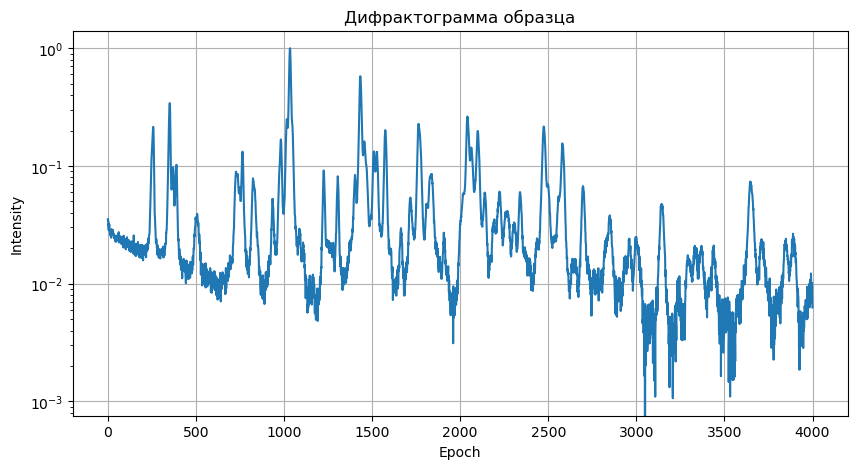

In [37]:
df_num = 40
start = 0
end = 1000
temp = np.zeros(train_inputs_np.shape[1])
print(temp.shape)


fig,ax = plt.subplots(figsize=(10,5))
# for i in range(len(train_inputs_np)):
#     temp += train_inputs_np[i]

# temp /= len(train_inputs_np)    
# ax.plot(temp)
ax.plot(train_inputs_np[0])
ax.set_title('Дифрактограмма образца')
ax.set_xlabel('Epoch')
ax.set_ylabel('Intensity')
ax.set_yscale('log')
ax.grid(True)
# ax.set_xlim(start,end)
# ax.legend(loc='lower left') # bbox_to_anchor=(1.03, 0.3)
plt.show()

# PCA Метод главных компонент

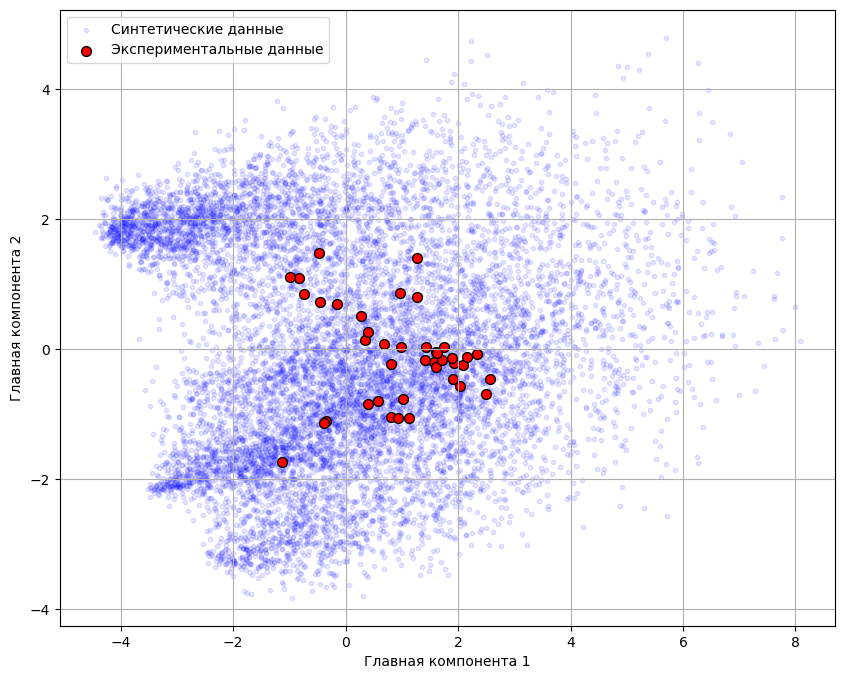

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import umap


X_synth = test_inputs_np  # Синтетика (взял 10к для скорости)
X_real = exp_data     # Ваши реальные эксперименты


# 2. Объединяем данные в один большой массив
X_combined = np.vstack((X_synth, X_real)) # Размер станет (10050, 4000)

# Создаем массив меток, чтобы потом раскрасить точки разными цветами
# 0 - это синтетика, 1 - это реальные данные
labels = np.array([0]*len(X_synth) + [1]*len(X_real))

# 3. Применяем PCA: сжимаем 4000 признаков (точек дифрактограммы) до 2-х координат
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_combined) # Размер станет (10050, 2)

# Разделяем обратно для удобства отрисовки
X_synth_pca = X_pca[labels == 0]
X_real_pca = X_pca[labels == 1]

# 4. Рисуем график
plt.figure(figsize=(10, 8))

# Рисуем синтетические данные (синие полупрозрачные точки)
plt.scatter(X_synth_pca[:, 0], X_synth_pca[:, 1], 
            c='blue', alpha=0.1, label='Синтетические данные', s=10)

# Рисуем реальные данные (красные яркие точки)
plt.scatter(X_real_pca[:, 0], X_real_pca[:, 1], 
            c='red', alpha=1.0, label='Экспериментальные данные', s=50, edgecolors='black')


plt.xlabel('Главная компонента 1')
plt.ylabel('Главная компонента 2')
plt.legend()
plt.grid(True)
plt.show()

# UMAP

/home/megalab/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


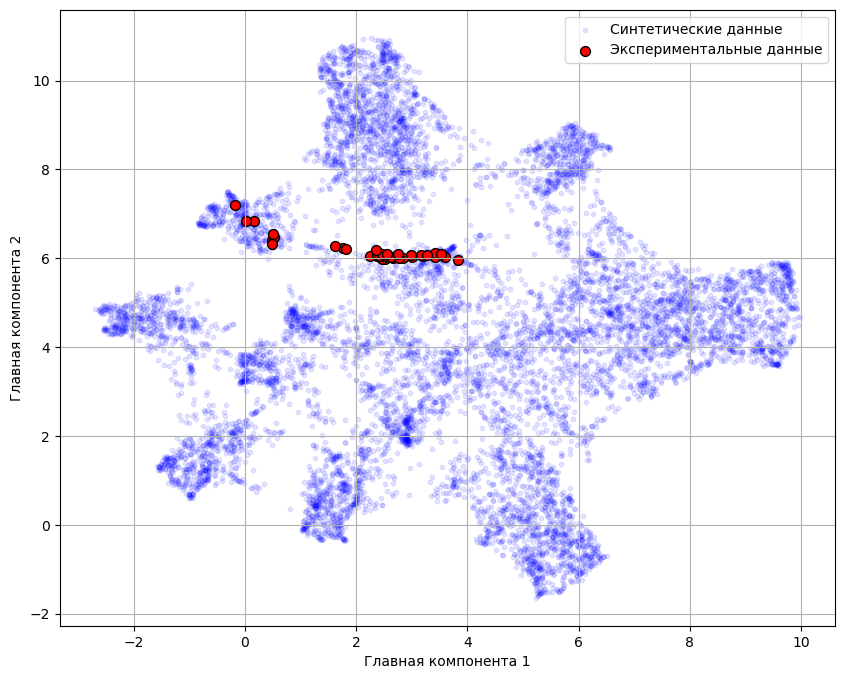

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import umap


X_synth = test_inputs_np  # Синтетика (взял 10к для скорости)
X_real = exp_data     # Ваши реальные эксперименты

# 2. Объединяем данные в один большой массив
X_combined = np.vstack((X_synth, X_real)) # Размер станет (10050, 4000)

# Создаем массив меток, чтобы потом раскрасить точки разными цветами
# 0 - это синтетика, 1 - это реальные данные
labels = np.array([0]*len(X_synth) + [1]*len(X_real))

# 3. Применяем PCA: сжимаем 4000 признаков (точек дифрактограммы) до 2-х координат
reducer = umap.UMAP() # n_neighbors=15, min_dist=0.1, metric='euclidean', random_state=42
X_pca = reducer.fit_transform(X_combined) # Размер станет (10050, 2)

# Разделяем обратно для удобства отрисовки
X_synth_pca = X_pca[labels == 0]
X_real_pca = X_pca[labels == 1]

# 4. Рисуем график
plt.figure(figsize=(10, 8))

# Рисуем синтетические данные (синие полупрозрачные точки)
plt.scatter(X_synth_pca[:, 0], X_synth_pca[:, 1], 
            c='blue', alpha=0.1, label='Синтетические данные', s=10)

# Рисуем реальные данные (красные яркие точки)
plt.scatter(X_real_pca[:, 0], X_real_pca[:, 1], 
            c='red', alpha=1.0, label='Экспериментальные данные', s=50, edgecolors='black',)


plt.xlabel('Главная компонента 1')
plt.ylabel('Главная компонента 2')
plt.legend()
plt.grid(True)
plt.show()

# UMAP + Расскраска по привалирующим фазам


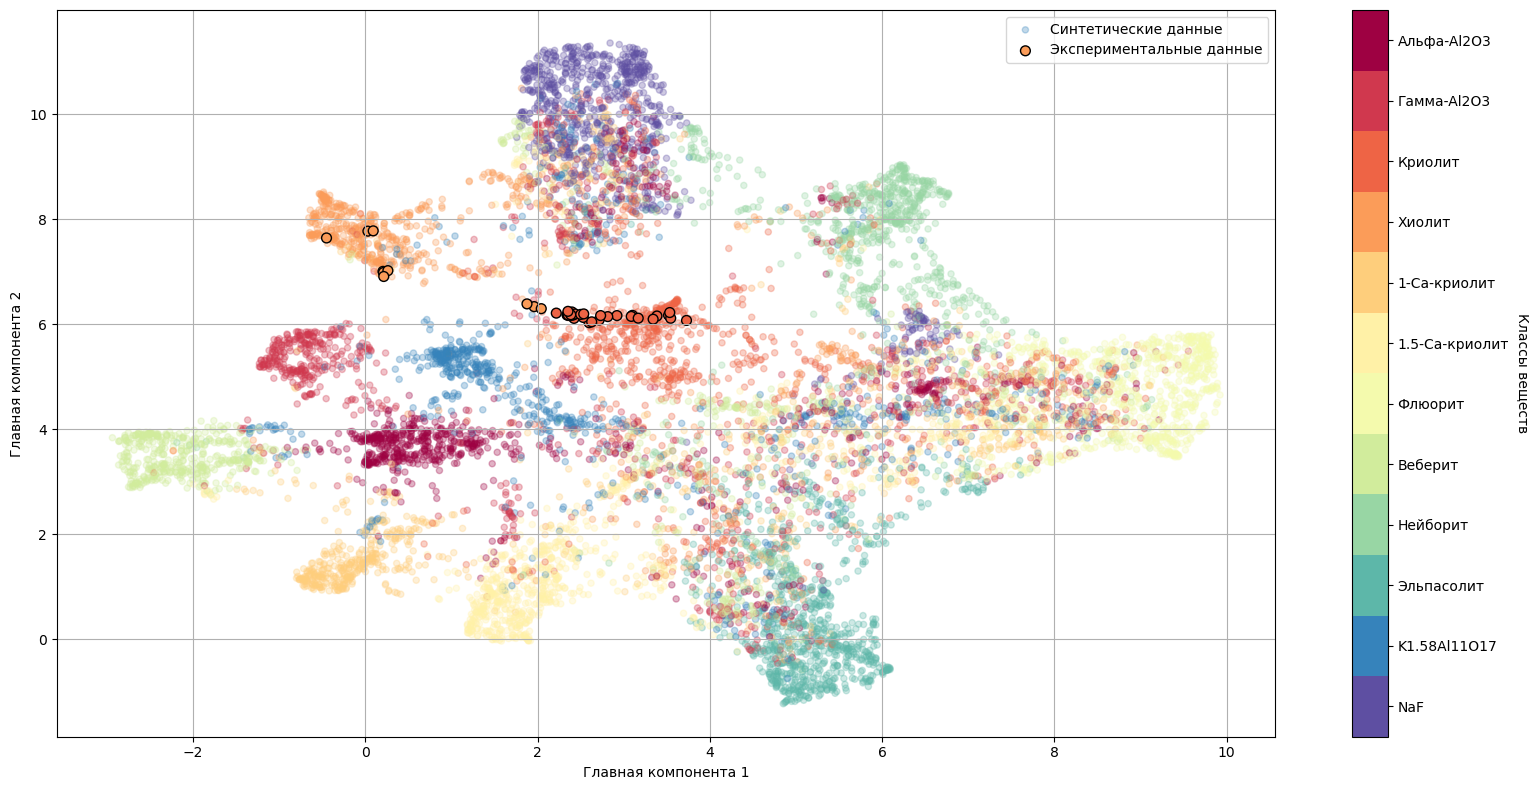

In [82]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import umap


X_synth = test_inputs_np  # Синтетика (взял 10к для скорости)
X_real = exp_data     # Ваши реальные эксперименты

adj_ph_synth = np.array([find_index_of_max(out) for out in test_outputs])
adj_ph_exp = np.array([find_index_of_max(out) for out in exp_data_phases])

# 2. Объединяем данные в один большой массив
X_combined = np.vstack((X_synth, X_real)) # Размер станет (10050, 4000)

# Создаем массив меток, чтобы потом раскрасить точки разными цветами
# 0 - это синтетика, 1 - это реальные данные
labels = np.array([0]*len(X_synth) + [1]*len(X_real))

# 3. Применяем PCA: сжимаем 4000 признаков (точек дифрактограммы) до 2-х координат
reducer = umap.UMAP() # n_neighbors=15, min_dist=0.1, metric='euclidean', random_state=42
X_pca = reducer.fit_transform(X_combined) 



# Создаем дискретную цветовую карту из 12 цветов. 
# 'Spectral' очень похожа на ту, что на вашей картинке. Можно также использовать 'tab20'
cmap = plt.get_cmap('Spectral', 12)


# Разделяем обратно для удобства отрисовки
X_synth_pca = X_pca[labels == 0]
X_real_pca = X_pca[labels == 1]

# 4. Рисуем график
plt.figure(figsize=(16, 8))

# Рисуем синтетические данные (синие полупрозрачные точки)
plt.scatter(X_synth_pca[:, 0], X_synth_pca[:, 1], 
            c=adj_ph_synth, 
            cmap=cmap,
            alpha=0.3, 
            label='Синтетические данные', 
            s=20,
            vmin=-0.5,   
            vmax=11.5)

# Рисуем реальные данные (красные яркие точки)
scatter = plt.scatter(X_real_pca[:, 0], X_real_pca[:, 1], 
            c=adj_ph_exp, 
            cmap=cmap,
            alpha=1.0, 
            label='Экспериментальные данные',
            s=50, 
            edgecolors='black',
            vmin=-0.5,  
            vmax=11.5,)

cbar = plt.colorbar(scatter, ticks=np.arange(12))
cbar.ax.invert_yaxis()
headers_rus = [
    'Альфа-Al2O3',
    'Гамма-Al2O3',
    'Криолит',
    'Хиолит',
    '1-Ca-криолит',
    '1.5-Ca-криолит',
    'Флюорит',
    'Веберит',
    'Нейборит',
    'Эльпасолит',
    'K1.58Al11O17',
    'NaF'
]


cbar.ax.set_yticklabels(headers_rus) # Раскомментируйте, чтобы показать названия вместо цифр
cbar.set_label('Классы веществ', rotation=270, labelpad=15)


plt.xlabel('Главная компонента 1')
plt.ylabel('Главная компонента 2')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# PCA + Расскраска по привалирующим фазам


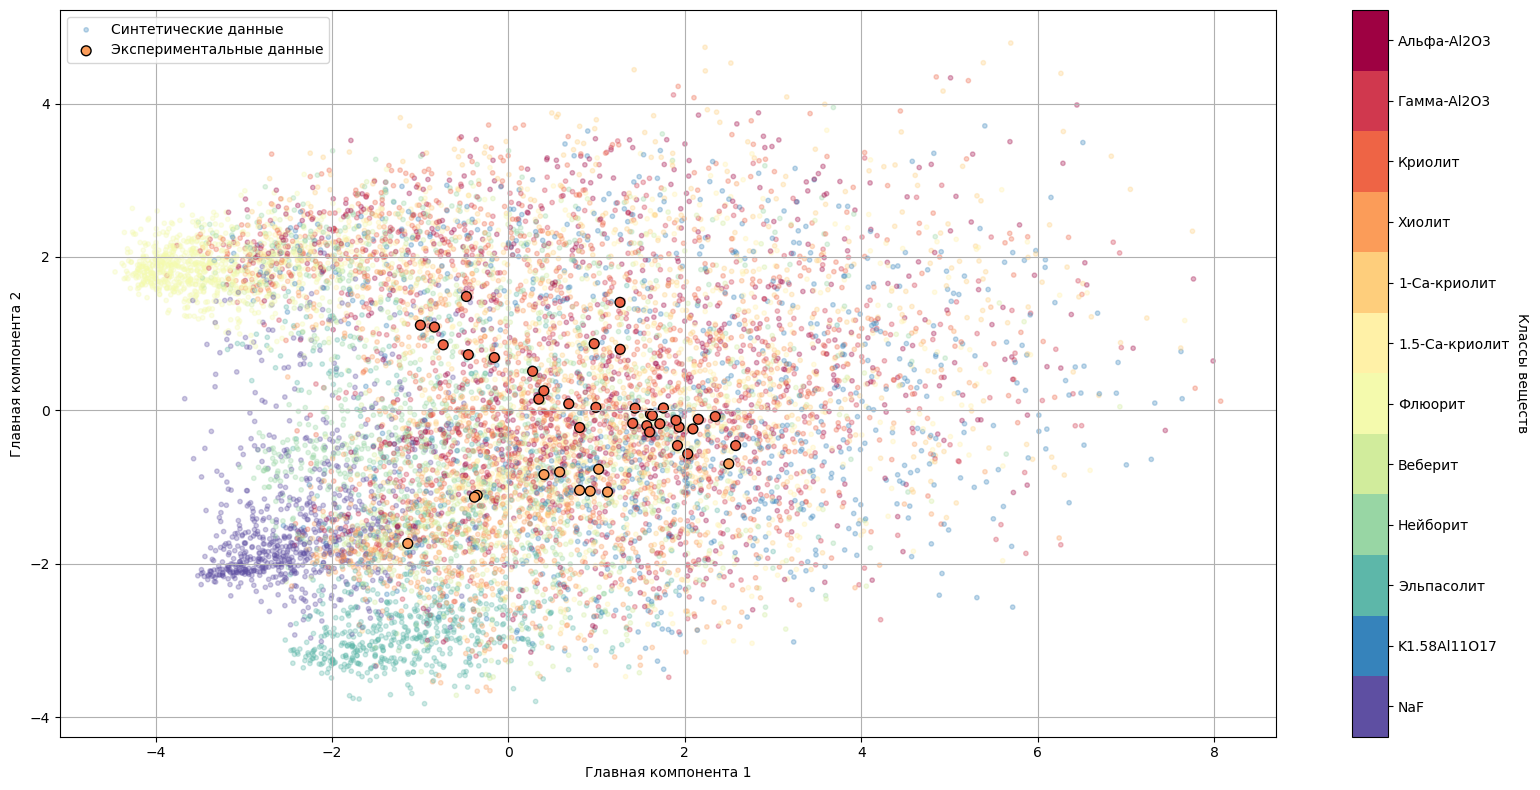

In [84]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import umap


X_synth = test_inputs_np  # Синтетика (взял 10к для скорости)
X_real = exp_data     # Ваши реальные эксперименты

adj_ph_synth = np.array([find_index_of_max(out) for out in test_outputs])
adj_ph_exp = np.array([find_index_of_max(out) for out in exp_data_phases])

# 2. Объединяем данные в один большой массив
X_combined = np.vstack((X_synth, X_real)) # Размер станет (10050, 4000)

# Создаем массив меток, чтобы потом раскрасить точки разными цветами
# 0 - это синтетика, 1 - это реальные данные
labels = np.array([0]*len(X_synth) + [1]*len(X_real))

# 3. Применяем PCA: сжимаем 4000 признаков (точек дифрактограммы) до 2-х координат
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_combined) # Размер станет (10050, 2) # Размер станет (10050, 2)



# Создаем дискретную цветовую карту из 12 цветов. 
# 'Spectral' очень похожа на ту, что на вашей картинке. Можно также использовать 'tab20'
cmap = plt.get_cmap('Spectral', 12)


# Разделяем обратно для удобства отрисовки
X_synth_pca = X_pca[labels == 0]
X_real_pca = X_pca[labels == 1]

# 4. Рисуем график
plt.figure(figsize=(16, 8))

# Рисуем синтетические данные (синие полупрозрачные точки)
plt.scatter(X_synth_pca[:, 0], X_synth_pca[:, 1], 
            c=adj_ph_synth, 
            cmap=cmap,
            alpha=0.3, 
            label='Синтетические данные', 
            s=10,
            vmin=-0.5,   
            vmax=11.5)

# Рисуем реальные данные (красные яркие точки)
scatter = plt.scatter(X_real_pca[:, 0], X_real_pca[:, 1], 
            c=adj_ph_exp, 
            cmap=cmap,
            alpha=1.0, 
            label='Экспериментальные данные',
            s=50, 
            edgecolors='black',
            vmin=-0.5,  
            vmax=11.5,)

cbar = plt.colorbar(scatter, ticks=np.arange(12))
cbar.ax.invert_yaxis()
headers_rus = [
    'Альфа-Al2O3',
    'Гамма-Al2O3',
    'Криолит',
    'Хиолит',
    '1-Ca-криолит',
    '1.5-Ca-криолит',
    'Флюорит',
    'Веберит',
    'Нейборит',
    'Эльпасолит',
    'K1.58Al11O17',
    'NaF'
]


cbar.ax.set_yticklabels(headers_rus) # Раскомментируйте, чтобы показать названия вместо цифр
cbar.set_label('Классы веществ', rotation=270, labelpad=15)


plt.xlabel('Главная компонента 1')
plt.ylabel('Главная компонента 2')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()